<a href="https://colab.research.google.com/github/sindhura-3ri/Artificial-Intelligence-1571/blob/main/IMDB_Sentiment_Analysis_project_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMDB Sentiment Analysis project using RNN

In [1]:
from keras.datasets import imdb
max_features = 10000
(xtrain,ytrain),(xtest,ytest)= imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(xtrain.shape)
print(xtest.shape)

(25000,)
(25000,)


In [4]:
sample_review = xtrain[0]
sample_pred = ytrain[0]
print(sample_review)
print("=========",sample_pred,sep="\n")

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


In [6]:
ytrain[:10]

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0])

## Word Index: Each word is given an index


In [9]:
len(xtrain)

25000

In [8]:
word_index = imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

## We will create reverse word index to know which index is given to which word

IMDB reserved first 3 words for padding and other important tasks

In [11]:
reverse_word_index = {index:word for word,index in word_index.items()}
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

**We can now see the sample review in text format**

In [14]:
dct = {1:"Raman",
       2:"Thaman",
       3: "Suman"}

In [15]:
dct.get(1)

'Raman'

In [16]:
dct.get(3)

'Suman'

In [18]:
dct.get(10,"NA")

'NA'

In [13]:
print(sample_review)

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [20]:
actual_review = [reverse_word_index.get(index-3,'?') for index in sample_review]
print(actual_review)

['?', 'this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', "everyone's", 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', '?', 'is', 'an', 'amazing', 'actor', 'and', 'now', 'the', 'same', 'being', 'director', '?', 'father', 'came', 'from', 'the', 'same', 'scottish', 'island', 'as', 'myself', 'so', 'i', 'loved', 'the', 'fact', 'there', 'was', 'a', 'real', 'connection', 'with', 'this', 'film', 'the', 'witty', 'remarks', 'throughout', 'the', 'film', 'were', 'great', 'it', 'was', 'just', 'brilliant', 'so', 'much', 'that', 'i', 'bought', 'the', 'film', 'as', 'soon', 'as', 'it', 'was', 'released', 'for', '?', 'and', 'would', 'recommend', 'it', 'to', 'everyone', 'to', 'watch', 'and', 'the', 'fly', 'fishing', 'was', 'amazing', 'really', 'cried', 'at', 'the', 'end', 'it', 'was', 'so', 'sad', 'and', 'you', 'know', 'what', 'they', 'say', 'if', 'you', 'cry', 'at', 'a', 'film', '

In [21]:
len(sample_review)

218

In [22]:
print(len(xtrain[0]))

218


In [23]:
print(len(xtrain[10]))

450


In [24]:
print(len(xtrain[15]))

129


## MOdels for text classification/sentiment analysis/text generation, we must provide input data with same length

### Padding
This can be done with the help of padding. Add extra zeros either at the beginning or at the end of the sentence

In [25]:
max_array_length = max([len(array) for array in xtrain]) #[218,450,129,......]
max_array_length # max([218,450,129,......]) = max value

2494

In [26]:
print(xtrain[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [27]:
from keras.preprocessing import sequence
xtrain = sequence.pad_sequences(xtrain,maxlen=max_array_length)
xtest = sequence.pad_sequences(xtest,maxlen=max_array_length)

In [28]:
print(xtrain[0])

[  0   0   0 ...  19 178  32]


## Model Buidling

In [29]:
len(xtrain[0])

2494

In [30]:
max_array_length

2494

In [32]:
from keras.models import Sequential
from keras.layers import Input,Dense,SimpleRNN,Dropout,Embedding
from keras.callbacks import EarlyStopping

# Intialize the Model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(max_array_length,)))

# Add the Embedding layer
model.add(Embedding(max_features,128))

# Add the Simple RNN layer
model.add(SimpleRNN(units=128,activation="tanh"))
# relu : >0 = 1 , <0 = 0
# tanh : >0 = 1, <0 = -1
model.add(Dropout(rate=0.2))

#Output layer
model.add(Dense(units=1,activation="sigmoid"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 2494, 128)      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [34]:
es = EarlyStopping(monitor="val_loss",patience=3)
nn = model.fit(xtrain,ytrain,validation_split=0.2,epochs=15,callbacks=[es])

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 212ms/step - accuracy: 0.5187 - loss: 0.7164 - val_accuracy: 0.5696 - val_loss: 0.6815
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.5975 - loss: 0.6593 - val_accuracy: 0.6168 - val_loss: 0.6448
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.7118 - loss: 0.5581 - val_accuracy: 0.6688 - val_loss: 0.6135
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 194ms/step - accuracy: 0.7984 - loss: 0.4450 - val_accuracy: 0.7290 - val_loss: 0.5981
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.8353 - loss: 0.3856 - val_accuracy: 0.7116 - val_loss: 0.5951
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.8723 - loss: 0.3169 - val_accuracy: 0.7420 - val_loss: 0.5836
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.9010 - loss: 0.2584 - val_accuracy: 0.7698 - val_loss: 0.5484
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 228ms/step - accuracy: 0.9281 -

## Learning curve

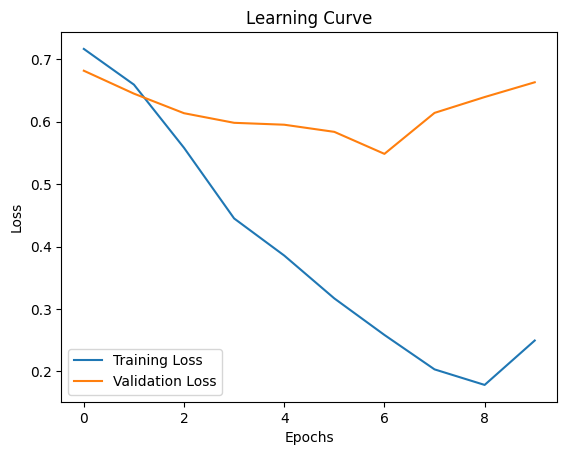

In [36]:
import matplotlib.pyplot as plt

plt.plot(nn.history["loss"],label="Training Loss")
plt.plot(nn.history["val_loss"],label="Validation Loss")
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [37]:
model.evaluate(xtrain,ytrain)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9205 - loss: 0.2321


[0.2320587933063507, 0.9204800128936768]

In [38]:
model.evaluate(xtest,ytest)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7571 - loss: 0.6344


[0.63435298204422, 0.7571200132369995]

## Classification report and Confusion matrix

In [40]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
yprobs = model.predict(xtest)

ypred = []

for i in yprobs:
  if i>0.5:
    ypred.append(1)
  else:
    ypred.append(0)

print(classification_report(ytest,ypred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     12500
           1       0.75      0.77      0.76     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



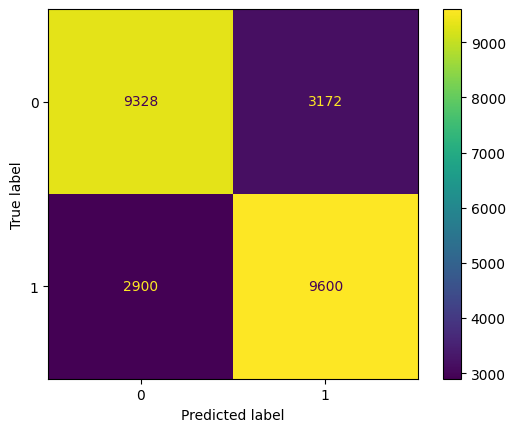

In [41]:
ConfusionMatrixDisplay.from_predictions(ytest,ypred)

## Save the model

In [42]:
model.save("IMDB Reviews.keras")

## Out of Sample Predictions

In [43]:
review = "The movie is fantastic. Would love to watch it again."

In [47]:
def preprocess_predict(text):
  text_token_index = [word_index.get(text,0) for text in review]
  # Padding
  text_token_index = sequence.pad_sequences([text_token_index],maxlen= max_array_length)
  # predict the possible probabilities
  probs = model.predict(text_token_index)
  if probs>0.5:
    return "Positive Review"
  else:
    return "Negative Review"

In [48]:
print(preprocess_predict(review))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
Positive Review
